<a href="https://colab.research.google.com/github/KittimaThongmual/Social-Media-Impact-on-Life/blob/main/lab15_project_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: ผลของการใช้โซเชียลมีเดียต่อระยะเวลาการนอนของนักเรียน/นักศึกษา
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นางสาวเบญจมาศ จ่านันท์ (68114540344)
- สมาชิกที่ 2: นางสาวกฤติมา ทองมวล (68114540045)

**Dataset:** Social Media Impact on Life (ไฟล์ `Social_media_impact_on_life-selected-columns.csv`, 4,500 แถว × 10 คอลัมน์) — แหล่งที่มา/URL: [https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life]

**Problem Statement:** โซเชียลมีเดียถูกใช้อย่างหนักในกลุ่มนักเรียนและนักศึกษา และหลายคนสงสัยว่าการใช้งานต่อวันที่มากขึ้นทำให้นอนน้อยลงหรือไม่ โครงงานนี้ใช้ข้อมูลนักเรียน/นักศึกษา 4,500 คน เพื่อวัดว่าชั่วโมงใช้โซเชียลมีเดียต่อวันอธิบายชั่วโมงการนอน (`Sleep_Duration_Hours`) ได้มากแค่ไหน และปัจจัยอื่น (อายุ, เพศ, ระดับการศึกษา, แพลตฟอร์ม, อุปกรณ์) ช่วยเพิ่มความแม่นยำได้หรือไม่

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |

In [ ]:
# ─── Import libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [ ]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์
# หมายเหตุ: วางไฟล์ CSV ไว้โฟลเดอร์เดียวกับ notebook นี้
CSV_PATH = 'Social_media_impact_on_life-selected-columns.csv'
df = pd.read_csv(CSV_PATH)

dup_ids = df['Student_ID'].duplicated().sum()
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicate Student_ID: {dup_ids}')
display(df.head())

Shape: (4500, 10)
Columns: ['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Primary_Platform', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Device_Type', 'Sleep_Duration_Hours', 'Sleep_Quality_Score']

Dtypes:
Student_ID                  str
Age                       int64
Gender                      str
Academic_Level              str
Primary_Platform            str
Daily_Usage_Hours       float64
Weekend_Extra_Hours     float64
Device_Type                 str
Sleep_Duration_Hours    float64
Sleep_Quality_Score       int64
dtype: object

Missing values:
Student_ID              0
Age                     0
Gender                  0
Academic_Level          0
Primary_Platform        0
Daily_Usage_Hours       0
Weekend_Extra_Hours     0
Device_Type             0
Sleep_Duration_Hours    0
Sleep_Quality_Score     0
dtype: int64

Duplicate Student_ID: 0


,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4


=== Numeric features ===


,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score
count,4500.00,4500.0,4500.0,4500.00,4500.00
mean,18.70,5.3,1.8,6.70,2.47
std,1.98,2.6,0.7,1.19,1.03
min,15.00,0.9,0.0,3.00,1.00
25%,17.00,3.4,1.3,6.00,2.00
50%,19.00,4.7,1.8,6.80,3.00
75%,20.00,6.6,2.3,7.50,3.00
max,26.00,14.0,4.5,10.50,5.00


=== Categorical features (counts) ===
Gender
Female               2234
Male                 2051
Non-Binary            122
Prefer not to say      93 

Academic_Level
Undergraduate    2777
High School      1477
Postgraduate      246 

Primary_Platform
Instagram      1453
TikTok         1226
YouTube         818
Snapchat        472
Reddit          229
X (Twitter)     206
LinkedIn         96 

Device_Type
Smartphone    3775
Laptop/PC      596
Tablet         129 



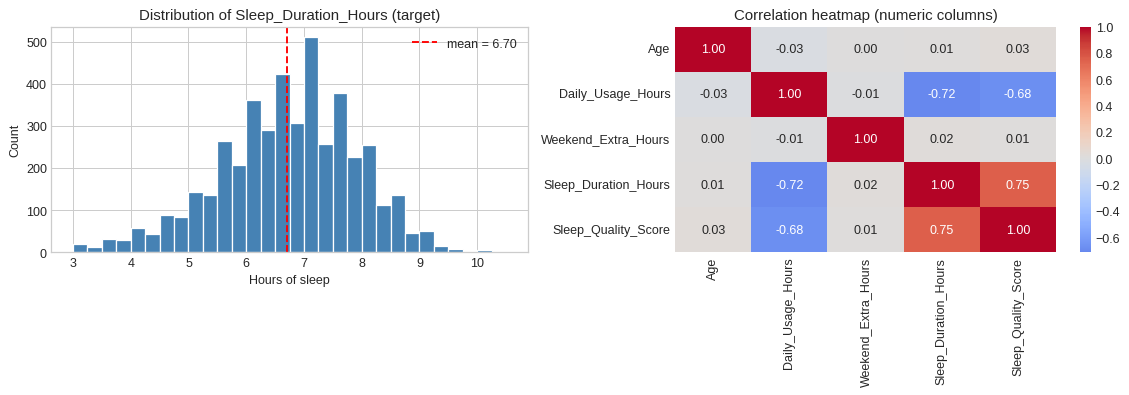

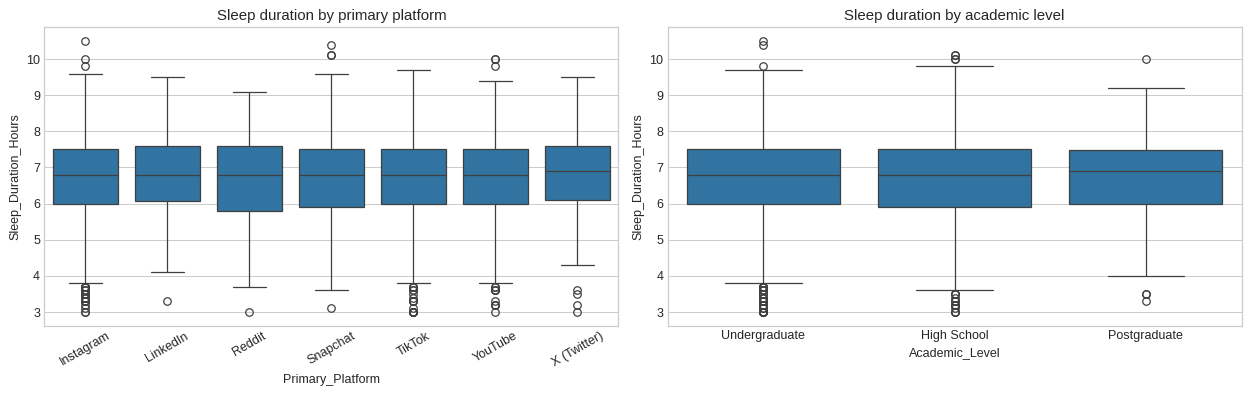

Mean usage / sleep by platform:


,Daily_Usage_Hours,Sleep_Duration_Hours
Primary_Platform,,
Snapchat,5.46,6.67
TikTok,5.33,6.68
Reddit,5.31,6.64
LinkedIn,5.27,6.75
Instagram,5.26,6.71
YouTube,5.25,6.72
X (Twitter),5.14,6.81


In [ ]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล
TARGET = 'Sleep_Duration_Hours'
num_cols = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours',
            'Sleep_Duration_Hours', 'Sleep_Quality_Score']
cat_cols = ['Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type']

# 1) Summary statistics
print('=== Numeric features ===')
display(df[num_cols].describe().round(2))
print('=== Categorical features (counts) ===')
for c in cat_cols:
    print(df[c].value_counts().to_string(), '\n')

# 2) Distribution ของ target + 3) Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df[TARGET], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df[TARGET].mean(), color='red', ls='--',
                label=f'mean = {df[TARGET].mean():.2f}')
axes[0].set(title='Distribution of Sleep_Duration_Hours (target)',
            xlabel='Hours of sleep', ylabel='Count')
axes[0].legend()
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1])
axes[1].set_title('Correlation heatmap (numeric columns)')
plt.tight_layout()
plt.show()

# 4) Target แยกตามกลุ่ม
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order = df.groupby('Primary_Platform')[TARGET].median().sort_values().index
sns.boxplot(data=df, x='Primary_Platform', y=TARGET, order=order, ax=axes[0])
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Sleep duration by primary platform')
sns.boxplot(data=df, x='Academic_Level', y=TARGET, ax=axes[1])
axes[1].set_title('Sleep duration by academic level')
plt.tight_layout()
plt.show()

print('Mean usage / sleep by platform:')
display(df.groupby('Primary_Platform')[['Daily_Usage_Hours', TARGET]].mean().round(2)
        .sort_values('Daily_Usage_Hours', ascending=False))

### 1.4 Preprocessing และแบ่ง Train/Test

การตัดสินใจสำคัญก่อนสร้างโมเดล:
- **Target:** `Sleep_Duration_Hours` (ต่อเนื่อง จึงใช้ Regression)
- **ไม่ใช้ `Sleep_Quality_Score` เป็น feature** เพราะเป็น "ผลลัพธ์ร่วม" ของการนอน (corr กับ target = 0.75) ไม่ใช่ตัวทำนายที่สมเหตุสมผล
- One-hot encode ตัวแปรหมวดหมู่ด้วย `drop_first=True`
- Scaler ถูก fit จาก train เท่านั้น เพื่อไม่ให้ข้อมูล test รั่วเข้ากระบวนการเรียนรู้

In [ ]:
# ─── Preprocessing + Train/Test split (ใช้ร่วมกันทุก Part ถัดไป) ─────
# - ตัด Student_ID (เป็นแค่ identifier)
# - ไม่ใช้ Sleep_Quality_Score เป็น feature เพราะเป็น "ผลลัพธ์ร่วม" ของการนอน (corr กับ target = 0.75)
# - One-hot encode ตัวแปรหมวดหมู่ (drop_first=True เพื่อเลี่ยง dummy variable trap)
feature_cols = ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours'] + cat_cols
X = pd.get_dummies(df[feature_cols], columns=cat_cols, drop_first=True).astype(float)
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale โดย fit บน train เท่านั้น (ป้องกัน data leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'X shape: {X.shape}  (features = {X.shape[1]})')
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print('Features:', X.columns.tolist())

X shape: (4500, 16)  (features = 16)
Train: 3600 rows | Test: 900 rows
Features: ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Gender_Male', 'Gender_Non-Binary', 'Gender_Prefer not to say', 'Academic_Level_Postgraduate', 'Academic_Level_Undergraduate', 'Primary_Platform_LinkedIn', 'Primary_Platform_Reddit', 'Primary_Platform_Snapchat', 'Primary_Platform_TikTok', 'Primary_Platform_X (Twitter)', 'Primary_Platform_YouTube', 'Device_Type_Smartphone', 'Device_Type_Tablet']


---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** กลุ่มเลือก **Task A + Task C** ร่วมกัน: standardize ตัวแปรตัวเลข 5 ตัว สร้าง covariance matrix (ซึ่งเท่ากับ correlation matrix) แล้วทำ eigendecomposition ด้วย `np.linalg.eigh` เพื่อหา principal components จากนั้นตรวจสอบผลด้วย SVD (eigenvalue = S²/(n−1)) และเทียบกับ `sklearn.PCA` เราคาดว่าจะเห็นแกนหลักที่รวมพฤติกรรม "ใช้โซเชียลมาก – นอนน้อย" เข้าด้วยกัน

C equals correlation matrix: True


,Eigenvalue,Explained variance,Cumulative
PC1,2.4319,0.4864,0.4864
PC2,1.0016,0.2003,0.6867
PC3,0.9972,0.1994,0.8861
PC4,0.3232,0.0646,0.9508
PC5,0.2462,0.0492,1.0000


SVD check  (S^2/(n-1) == eigenvalues): True
sklearn PCA check (explained ratio): True

Loadings (columns = eigenvectors):


,PC1,PC2,PC3,PC4,PC5
Age,-0.029,0.654,0.756,0.004,0.019
Daily_Usage_Hours,0.568,0.016,-0.002,0.790,0.229
Weekend_Extra_Hours,-0.016,0.756,-0.655,-0.004,-0.005
Sleep_Duration_Hours,-0.586,-0.025,-0.022,0.194,0.786
Sleep_Quality_Score,-0.577,-0.013,-0.000,0.581,-0.574


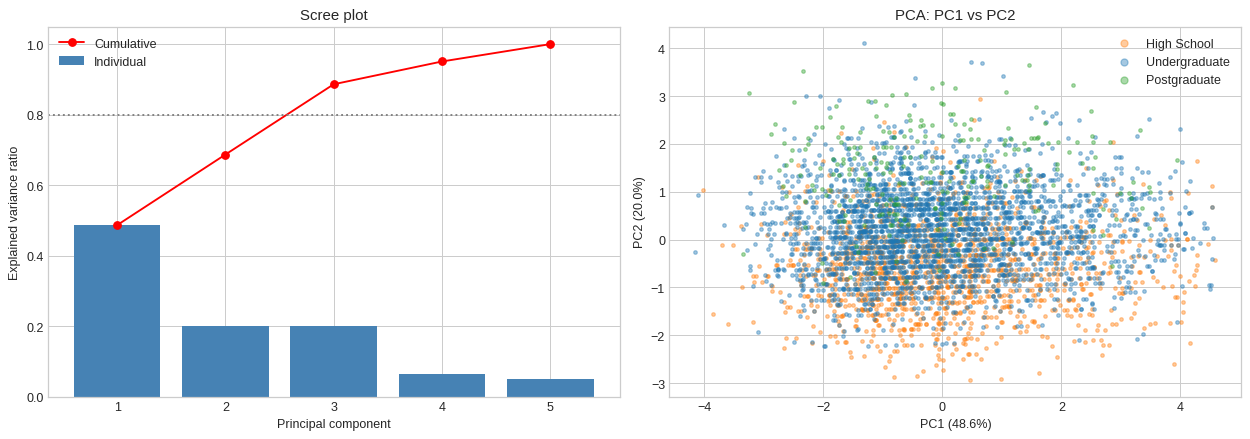

In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: Task A (PCA) + Task C (eigendecomposition ของ correlation matrix)
#             + ตรวจสอบผลด้วย SVD และเทียบกับ sklearn.PCA
pca_cols = num_cols
Xn = df[pca_cols].values.astype(float)
Xn_std = (Xn - Xn.mean(axis=0)) / Xn.std(axis=0, ddof=1)   # standardize
n = Xn_std.shape[0]

# 1) Covariance matrix ของข้อมูลที่ standardize แล้ว (= correlation matrix)
C = (Xn_std.T @ Xn_std) / (n - 1)
print('C equals correlation matrix:', np.allclose(C, df[pca_cols].corr().values))

# 2) Eigendecomposition (C สมมาตร -> ใช้ eigh) แล้วเรียงจากมากไปน้อย
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

pc_names = [f'PC{i+1}' for i in range(len(pca_cols))]
summary = pd.DataFrame({'Eigenvalue': eigvals, 'Explained variance': explained,
                        'Cumulative': cum_explained}, index=pc_names).round(4)
display(summary)

# 3) ตรวจสอบด้วย SVD: eigenvalues = S^2 / (n-1)
U, S, Vt = np.linalg.svd(Xn_std, full_matrices=False)
print('SVD check  (S^2/(n-1) == eigenvalues):', np.allclose(S**2 / (n - 1), eigvals))

# 4) เทียบกับ sklearn.PCA
pca = PCA().fit(Xn_std)
print('sklearn PCA check (explained ratio):', np.allclose(pca.explained_variance_ratio_, explained))

# 5) Loadings (eigenvectors) -> features ไหน contribute กับแต่ละ PC
loadings = pd.DataFrame(eigvecs, index=pca_cols, columns=pc_names).round(3)
print('\nLoadings (columns = eigenvectors):')
display(loadings)

# 6) Scree plot + 2D projection
scores = Xn_std @ eigvecs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(eigvals) + 1), explained, color='steelblue', label='Individual')
axes[0].plot(range(1, len(eigvals) + 1), cum_explained, 'o-', color='red', label='Cumulative')
axes[0].axhline(0.8, color='gray', ls=':')
axes[0].set(title='Scree plot', xlabel='Principal component',
            ylabel='Explained variance ratio', xticks=range(1, len(eigvals) + 1))
axes[0].legend()

for level, color in zip(['High School', 'Undergraduate', 'Postgraduate'],
                        ['tab:orange', 'tab:blue', 'tab:green']):
    m = (df['Academic_Level'] == level).values
    axes[1].scatter(scores[m, 0], scores[m, 1], s=8, alpha=0.4, c=color, label=level)
axes[1].set(title='PCA: PC1 vs PC2', xlabel=f'PC1 ({explained[0]*100:.1f}%)',
            ylabel=f'PC2 ({explained[1]*100:.1f}%)')
axes[1].legend(markerscale=2)
plt.tight_layout()
plt.show()

**Insight จาก CLO1 Analysis:**
> - **PC1 อธิบาย variance ได้ 48.6%** และเป็นแกนเดียวที่มีโครงสร้างชัดเจน: loading ของ `Daily_Usage_Hours` เป็นบวก (+0.57) ส่วน `Sleep_Duration_Hours` (−0.59) และ `Sleep_Quality_Score` (−0.58) เป็นลบ ส่วน Age และ Weekend_Extra_Hours แทบเป็น 0 แปลว่า PC1 คือแกน "ใช้โซเชียลมาก ↔ นอนน้อยและคุณภาพการนอนต่ำ"
> - **PC2 และ PC3 มี eigenvalue ≈ 1.00** (20.0% และ 19.9%) ซึ่งเท่ากับความแปรปรวนของตัวแปรเดี่ยวหลัง standardize จึงเป็นเพียง Age กับ Weekend_Extra_Hours ที่ไม่สัมพันธ์กับตัวแปรอื่น (loading ผสมกันเพราะ eigenvalue ซ้ำกัน ทิศทางจึงหมุนได้อิสระ) ไม่ใช่โครงสร้างใหม่
> - PC1–PC3 รวมกันได้ 88.6% แต่ส่วนที่มีความหมายจริงคือ PC1 ตัวเดียว การลด dimension จาก 5 เหลือ 1 จึงเก็บความสัมพันธ์หลักของข้อมูลไว้ได้
> - ตรวจสอบแล้วว่าผลจาก eigendecomposition, SVD และ `sklearn.PCA` ตรงกัน

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

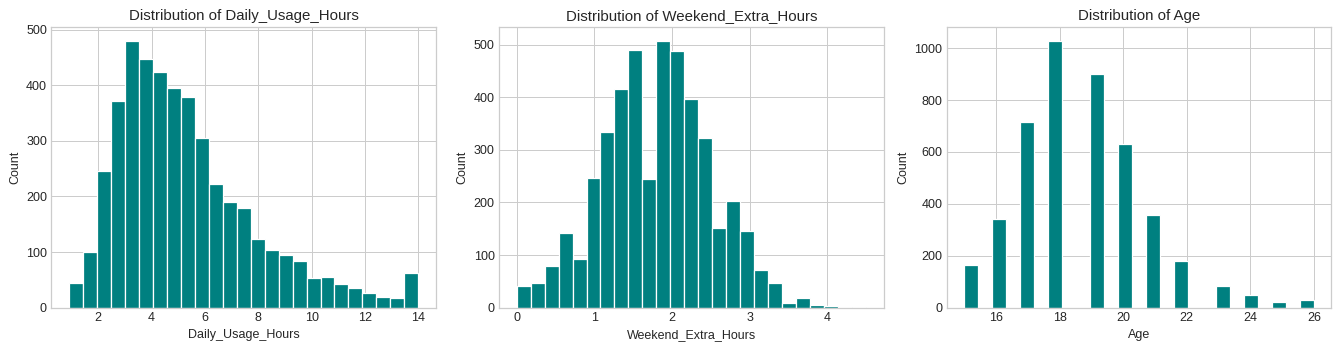

Skewness of Daily_Usage_Hours: 1.13

Correlation with target (Sleep_Duration_Hours):
Sleep_Quality_Score    0.748
Daily_Usage_Hours     -0.716
Weekend_Extra_Hours    0.017
Age                    0.013

Pearson r (Daily_Usage vs Sleep) = -0.716, p-value = 0.00e+00

VIF (สูง = features สัมพันธ์กันเอง):
Age                             2.40
Academic_Level_Postgraduate     2.30
Academic_Level_Undergraduate    1.93
Primary_Platform_TikTok         1.35
Primary_Platform_YouTube        1.28
Primary_Platform_Snapchat       1.20


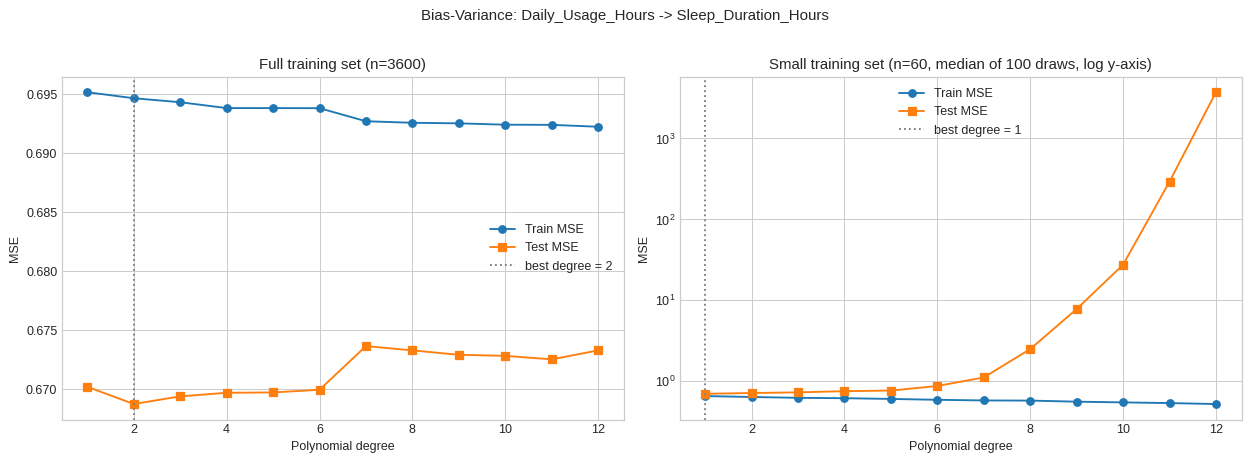

Full train  -> best degree by Test MSE: 2 | Test MSE = 0.6687
Small train -> best degree by Test MSE: 1 | Test MSE = 0.6860
Small train, degree 12: Train MSE = 0.5116, Test MSE = 3732.9552


In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset
from scipy import stats

# 1) Distributions ของ features สำคัญ
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Age']):
    ax.hist(df[col], bins=25, color='teal', edgecolor='white')
    ax.set(title=f'Distribution of {col}', xlabel=col, ylabel='Count')
plt.tight_layout()
plt.show()
print(f"Skewness of Daily_Usage_Hours: {stats.skew(df['Daily_Usage_Hours']):.2f}")

# 2) Correlation ของ numeric features กับ target
corr_target = df[num_cols].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('\nCorrelation with target (Sleep_Duration_Hours):')
print(corr_target.round(3).to_string())
r, p = stats.pearsonr(df['Daily_Usage_Hours'], df[TARGET])
print(f'\nPearson r (Daily_Usage vs Sleep) = {r:.3f}, p-value = {p:.2e}')

# 2.1) Multicollinearity: VIF = diagonal ของ inverse correlation matrix
R = np.corrcoef(X_train_s, rowvar=False)
vif = pd.Series(np.diag(np.linalg.inv(R)), index=X.columns).sort_values(ascending=False)
print('\nVIF (สูง = features สัมพันธ์กันเอง):')
print(vif.round(2).head(6).to_string())

# 3) Bias-Variance U-curve: polynomial degree vs Train/Test MSE
def poly_model(d):
    return make_pipeline(StandardScaler(), PolynomialFeatures(d, include_bias=False),
                         LinearRegression())

xtr = X_train[['Daily_Usage_Hours']].values
xte = X_test[['Daily_Usage_Hours']].values
degrees = list(range(1, 13))

def curve(x_train, y_train_, reps):
    tr = np.zeros((reps, len(degrees))); te = np.zeros((reps, len(degrees)))
    for k in range(reps):
        if reps > 1:                       # สุ่ม train ขนาดเล็ก 60 แถว
            sel = np.random.choice(len(x_train), 60, replace=False)
            xs, ys = x_train[sel], y_train_[sel]
        else:
            xs, ys = x_train, y_train_
        for i, d in enumerate(degrees):
            m = poly_model(d).fit(xs, ys)
            tr[k, i] = mean_squared_error(ys, m.predict(xs))
            te[k, i] = mean_squared_error(y_test, m.predict(xte))
    return np.median(tr, axis=0), np.median(te, axis=0)   # median กัน outlier ที่ degree สูง

tr_full, te_full = curve(xtr, y_train, 1)           # ใช้ train ทั้งหมด
tr_small, te_small = curve(xtr, y_train, 100)       # train แค่ 60 แถว (สุ่ม 100 ครั้ง)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, te, ttl in zip(axes, [tr_full, tr_small], [te_full, te_small],
                           [f'Full training set (n={len(xtr)})',
                            'Small training set (n=60, median of 100 draws, log y-axis)']):
    ax.plot(degrees, tr, 'o-', label='Train MSE')
    ax.plot(degrees, te, 's-', label='Test MSE')
    ax.axvline(degrees[int(np.argmin(te))], color='gray', ls=':',
               label=f'best degree = {degrees[int(np.argmin(te))]}')
    ax.set(title=ttl, xlabel='Polynomial degree', ylabel='MSE')
    ax.legend()
axes[1].set_yscale('log')
plt.suptitle('Bias-Variance: Daily_Usage_Hours -> Sleep_Duration_Hours', y=1.02)
plt.tight_layout()
plt.show()

print('Full train  -> best degree by Test MSE:', degrees[int(np.argmin(te_full))],
      f'| Test MSE = {te_full.min():.4f}')
print('Small train -> best degree by Test MSE:', degrees[int(np.argmin(te_small))],
      f'| Test MSE = {te_small.min():.4f}')
print(f'Small train, degree 12: Train MSE = {tr_small[-1]:.4f}, Test MSE = {te_small[-1]:.4f}')

**Insight จาก CLO2 Analysis:**
> - **Target:** `Sleep_Duration_Hours` มีค่าเฉลี่ย 6.70 ชม. (SD 1.19) รูปร่างค่อนข้างสมมาตร จึงเหมาะกับ Regression
> - **Feature สำคัญที่สุดคือ `Daily_Usage_Hours`** (r = −0.716, p ≈ 0) ส่วน Age (0.013) และ Weekend_Extra_Hours (0.017) แทบไม่สัมพันธ์กับ target ส่วน `Daily_Usage_Hours` มี skewness 1.13 (เบ้ขวา มีคนใช้หนักมาก)
> - VIF สูงสุดเพียง 2.40 (Age) จึงไม่มีปัญหา multicollinearity รุนแรงแม้ Age สัมพันธ์กับ Academic_Level
> - **Bias–Variance:** เมื่อใช้ train ทั้งหมด (n=3,600) Test MSE เกือบแบนราบทุก degree (ต่ำสุดที่ degree 2 = 0.6687 ต่างจาก degree อื่นเพียงไม่ถึง 0.01) เพราะความสัมพันธ์เกือบเป็นเส้นตรงและข้อมูลมาก แต่เมื่อใช้ train เพียง 60 แถว จะเห็น U-curve ชัดเจน: degree ที่ดีที่สุดคือ 1 (Test MSE ≈ 0.686) ส่วน degree 12 มี Train MSE ต่ำลงเหลือ ≈ 0.51 แต่ Test MSE พุ่งเป็นหลักพัน (overfitting / high variance)
> - **Optimal complexity:** degree 1–2 (โมเดลง่ายก็เพียงพอ)

# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

Intercept = 8.434
Slope     = -0.328 hours of sleep per +1 hour of daily usage


,Model,Train MSE,Test MSE,Train R2,Test R2,Test MAE
0,Model 1: Simple LR,0.6952,0.6702,0.5146,0.5032,0.6646


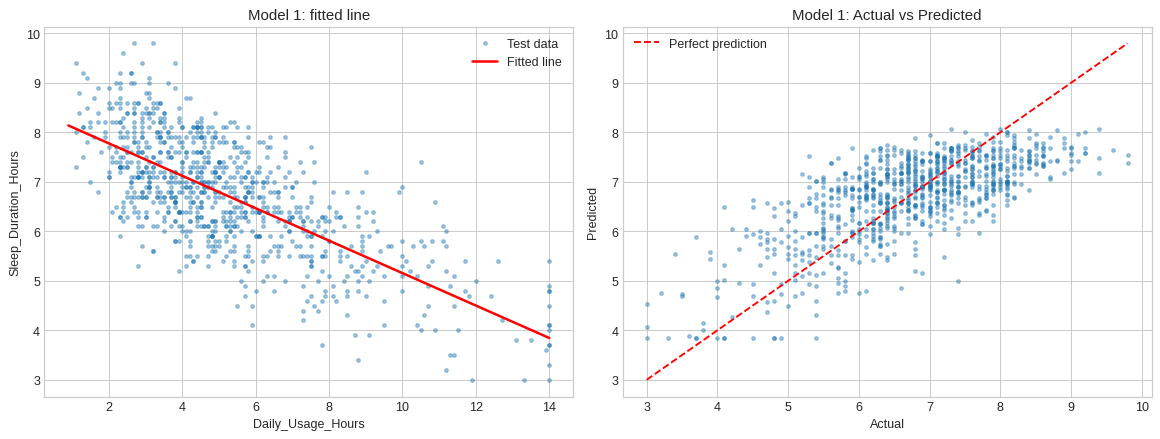

In [ ]:
# ─── CLO3: Model 1 — Simple Linear Regression ──────────────────────
# วัตถุประสงค์: ทำนาย Sleep_Duration จาก Daily_Usage_Hours (feature ที่ correlate สูงสุด)
def evaluate(model, Xtr, Xte, name):
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    return {'Model': name,
            'Train MSE': mean_squared_error(y_train, ptr), 'Test MSE': mean_squared_error(y_test, pte),
            'Train R2': r2_score(y_train, ptr), 'Test R2': r2_score(y_test, pte),
            'Test MAE': mean_absolute_error(y_test, pte)}

x1_train = X_train[['Daily_Usage_Hours']]
x1_test = X_test[['Daily_Usage_Hours']]

model1 = LinearRegression()
model1.fit(x1_train, y_train)
print(f'Intercept = {model1.intercept_:.3f}')
print(f'Slope     = {model1.coef_[0]:.3f} hours of sleep per +1 hour of daily usage')
res1 = evaluate(model1, x1_train, x1_test, 'Model 1: Simple LR')
display(pd.DataFrame([res1]).round(4))

pred1 = model1.predict(x1_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(x1_test, y_test, s=8, alpha=0.4, label='Test data')
xs = np.linspace(x1_train.min(), x1_train.max(), 100).reshape(-1, 1)
axes[0].plot(xs, model1.predict(pd.DataFrame(xs, columns=['Daily_Usage_Hours'])),
             color='red', lw=2, label='Fitted line')
axes[0].set(title='Model 1: fitted line', xlabel='Daily_Usage_Hours', ylabel='Sleep_Duration_Hours')
axes[0].legend()
axes[1].scatter(y_test, pred1, s=8, alpha=0.4)
lim = [y_test.min(), y_test.max()]
axes[1].plot(lim, lim, 'r--', label='Perfect prediction')
axes[1].set(title='Model 1: Actual vs Predicted', xlabel='Actual', ylabel='Predicted')
axes[1].legend()
plt.tight_layout()
plt.show()

,Train MSE,Test MSE,Train R2,Test R2,Test MAE
Model,,,,,
Model 1: Simple LR,0.6952,0.6702,0.5146,0.5032,0.6646
Model 2: Multiple LR,0.6940,0.6713,0.5155,0.5023,0.6664
Model 2b: Ridge (alpha=10),0.6940,0.6713,0.5155,0.5024,0.6663


Coefficients of Model 2 (per +1 SD of each feature), top 8:
Daily_Usage_Hours              -0.859
Age                            -0.029
Academic_Level_Postgraduate     0.025
Academic_Level_Undergraduate    0.020
Primary_Platform_X (Twitter)    0.017
Device_Type_Tablet             -0.012
Gender_Non-Binary              -0.009
Primary_Platform_TikTok        -0.009


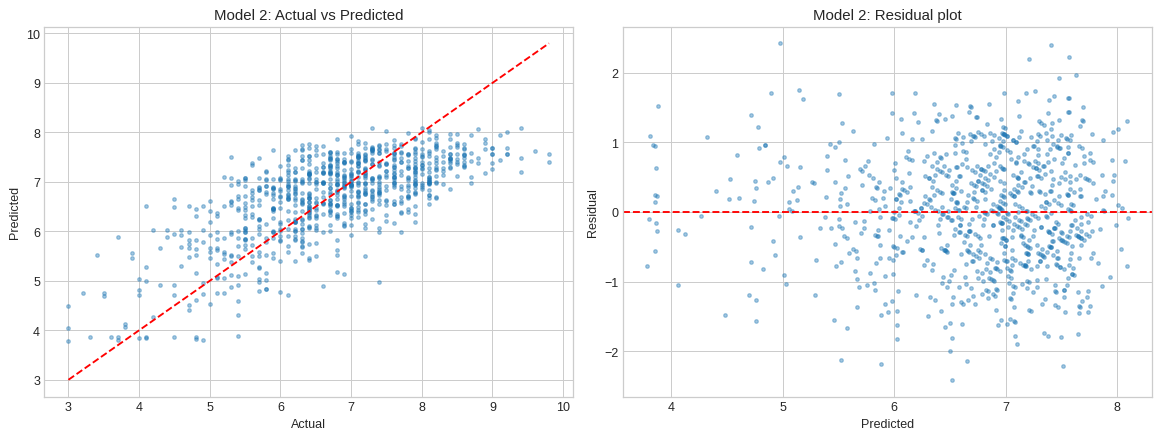

In [ ]:
# ─── CLO3: Model 2 — Multiple Linear Regression (ทุก features) ─────
# วัตถุประสงค์: เพิ่ม features ทั้งหมด (standardized) แล้วดูว่า test error ดีขึ้นไหม
model2 = LinearRegression()
model2.fit(X_train_s, y_train)
res2 = evaluate(model2, X_train_s, X_test_s, 'Model 2: Multiple LR')

# Model 2b: Ridge (ใช้เปรียบเทียบเพิ่มเติม)
model2b = Ridge(alpha=10.0)
model2b.fit(X_train_s, y_train)
res2b = evaluate(model2b, X_train_s, X_test_s, 'Model 2b: Ridge (alpha=10)')

results = pd.DataFrame([res1, res2, res2b]).set_index('Model').round(4)
display(results)

# Coefficients (standardized -> เทียบขนาดอิทธิพลกันได้)
coef = pd.Series(model2.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('Coefficients of Model 2 (per +1 SD of each feature), top 8:')
print(coef.round(3).head(8).to_string())

pred2 = model2.predict(X_test_s)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred2, s=8, alpha=0.4)
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set(title='Model 2: Actual vs Predicted', xlabel='Actual', ylabel='Predicted')
axes[1].scatter(pred2, y_test - pred2, s=8, alpha=0.4)
axes[1].axhline(0, color='red', ls='--')
axes[1].set(title='Model 2: Residual plot', xlabel='Predicted', ylabel='Residual')
plt.tight_layout()
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric (MSE / R²) | Test Metric (MSE / R²) | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: Simple LR | 0.6952 / 0.5146 | 0.6702 / 0.5032 | `Daily_Usage_Hours` ตัวเดียว, slope = −0.328, intercept = 8.43 |
| Model 2: Multiple LR | 0.6940 / 0.5155 | 0.6713 / 0.5023 | ทุก feature (16 ตัวหลัง one-hot, standardized) |
| Model 2b: Ridge (α=10) | 0.6940 / 0.5155 | 0.6713 / 0.5024 | Multiple LR + L2 regularization |

**Insight:**
> - Simple LR ตีความได้ตรงๆ: **ใช้โซเชียลมีเดียเพิ่มขึ้น 1 ชม./วัน เวลานอนลดลงเฉลี่ยประมาณ 0.33 ชม. (~20 นาที)** และโมเดลอธิบาย variance ของเวลานอนได้ราว 50%
> - การเพิ่ม feature อีก 15 ตัว **ไม่ช่วยให้ดีขึ้น** (Test MSE 0.6713 เทียบกับ 0.6702) ใน Multiple LR ค่า coefficient ของ `Daily_Usage_Hours` คือ −0.859 ต่อ 1 SD ขณะที่ feature อื่นทุกตัวมีขนาด < 0.03
> - ไม่พบ overfitting: Train และ Test MSE ใกล้เคียงกัน (Test ต่ำกว่า Train เล็กน้อยจากการสุ่มแบ่งข้อมูล) และ Ridge ให้ผลเกือบเท่า Multiple LR เพราะ features น้อยและข้อมูลมาก การทำ regularization จึงไม่มีผลชัดเจน
> - อาจมี **underfitting บางส่วน**: R² ≈ 0.50 หมายความว่ายังมี variance อีกราวครึ่งที่ features ในชุดข้อมูลนี้อธิบายไม่ได้

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Ridge CV MSE by alpha: {0.01: 0.7013, 0.1: 0.7013, 1: 0.7013, 10: 0.7013, 100: 0.7019, 1000: 0.7489}
Best alpha: 10 

Simple LR (Daily only): CV MSE = 0.6962 (+/- 0.0191)
Poly deg 2 (Daily only): CV MSE = 0.6959 (+/- 0.0192)
Multiple LR (all features): CV MSE = 0.7013 (+/- 0.0187)
Ridge (alpha=10): CV MSE = 0.7013 (+/- 0.0188)


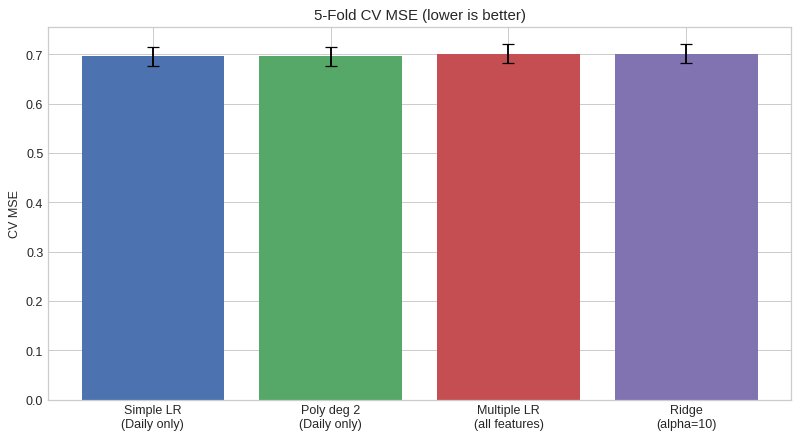


Best model by CV: Poly deg 2 (Daily only)
Held-out test MSE = 0.6687 | R2 = 0.5043


In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV (ใช้ train set เท่านั้น เก็บ test set ไว้ประเมินตอนท้าย)
# ใช้ Pipeline เพื่อให้ scaling ถูก fit ใหม่ในแต่ละ fold (ไม่มี leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_mse(model):
    s = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    return -s.mean(), s.std()

only_daily = ColumnTransformer([('sel', 'passthrough', ['Daily_Usage_Hours'])])

# เลือก alpha ของ Ridge ด้วย CV
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = {a: cv_mse(make_pipeline(StandardScaler(), Ridge(alpha=a)))[0] for a in alphas}
best_alpha = min(ridge_cv, key=ridge_cv.get)
print('Ridge CV MSE by alpha:', {a: round(float(v), 4) for a, v in ridge_cv.items()})
print('Best alpha:', best_alpha, '\n')

models = {
    'Simple LR\n(Daily only)': make_pipeline(only_daily, LinearRegression()),
    'Poly deg 2\n(Daily only)': make_pipeline(only_daily, StandardScaler(),
                                              PolynomialFeatures(2, include_bias=False), LinearRegression()),
    'Multiple LR\n(all features)': make_pipeline(StandardScaler(), LinearRegression()),
    f'Ridge\n(alpha={best_alpha})': make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
}

rows = []
for name, model in models.items():
    m, s = cv_mse(model)
    rows.append({'Model': name.replace('\n', ' '), 'CV MSE': m, 'CV std': s})
    print(f"{name.replace(chr(10), ' ')}: CV MSE = {m:.4f} (+/- {s:.4f})")
cv_table = pd.DataFrame(rows).set_index('Model')

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(list(models.keys()), cv_table['CV MSE'], yerr=cv_table['CV std'], capsize=5,
       color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
ax.set(title='5-Fold CV MSE (lower is better)', ylabel='CV MSE')
plt.tight_layout()
plt.show()

# ประเมิน best model บน test set ครั้งเดียว
best_name = cv_table['CV MSE'].idxmin()
best_key = [k for k in models if k.replace('\n', ' ') == best_name][0]
best_model = models[best_key].fit(X_train, y_train)
test_pred = best_model.predict(X_test)
print(f'\nBest model by CV: {best_name}')
print(f'Held-out test MSE = {mean_squared_error(y_test, test_pred):.4f} | '
      f'R2 = {r2_score(y_test, test_pred):.4f}')

**Best Model จาก Cross-Validation:** Polynomial degree 2 (`Daily_Usage_Hours` ตัวเดียว) โดยตัวเลขต่ำสุด แต่ **Simple Linear Regression ให้ผลเทียบเท่ากันในทางปฏิบัติ**

**เหตุผล:**
> - 5-Fold CV MSE (train set): Poly deg 2 = **0.6959**, Simple LR = 0.6962, Multiple LR = 0.7013, Ridge (α=10, เลือกจาก CV) = 0.7013
> - ความต่างระหว่าง Poly deg 2 กับ Simple LR (0.0003) เล็กกว่า SD ของ CV (≈ 0.019) มาก จึงถือว่าไม่ต่างกันเชิงสถิติ ตามหลัก parsimony ควรเลือก **Simple LR** ที่ง่ายกว่าและตีความได้ (ส่วนโมเดลที่ใช้ทุก feature กลับแย่กว่าเล็กน้อย เพราะ feature เพิ่มเติมเป็น noise เพิ่ม variance โดยไม่ลด bias)
> - เมื่อประเมิน best model (Poly deg 2) บน test set ที่กันไว้: MSE = 0.6687, R² = 0.5043 สอดคล้องกับผล CV (ไม่ overfit)
> - เชื่อมกับ Bias–Variance: ความสัมพันธ์ใกล้เส้นตรง ความซับซ้อนที่เพิ่มขึ้นไม่ลด bias (ไม่มีอะไรให้ลด) และมีแต่จะเพิ่ม variance ดังที่เห็นใน U-curve ของ Part 3

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
- **CLO1:** PCA/eigendecomposition พบแกนหลัก PC1 (48.6% ของ variance) ที่รวม "ใช้โซเชียลมาก – นอนน้อย – คุณภาพการนอนต่ำ" ไว้ด้วยกัน ส่วน Age กับ Weekend_Extra_Hours เป็นมิติอิสระที่ไม่เกี่ยวกับการนอน
- **CLO2:** `Daily_Usage_Hours` สัมพันธ์กับเวลานอนสูงสุด (r = −0.716) ส่วน feature อื่นแทบไม่มีผล; U-curve แสดงว่าโมเดลง่าย (degree 1–2) เหมาะที่สุด
- **CLO3:** Simple LR (Test MSE 0.670, R² 0.503) ดีเท่ากับ Multiple LR/Ridge; ใช้โซเชียลเพิ่ม 1 ชม./วัน เวลานอนลดลงราว 0.33 ชม.
- **CLO4:** 5-Fold CV ชี้ว่า Poly deg 2 และ Simple LR ไม่ต่างกัน (CV MSE ≈ 0.696) และดีกว่าโมเดลที่ใช้ทุก feature (0.701)

**6.2 Limitations:**
- ข้อมูลเป็น cross-sectional จึงบอกได้เพียง **ความสัมพันธ์** ไม่ใช่เหตุและผล (คนที่นอนไม่หลับอาจใช้โซเชียลมากขึ้นก็ได้)
- Features ที่มีน้อยและเกือบไม่ให้ข้อมูลเพิ่มนอกจาก Daily_Usage; R² จึงหยุดที่ ~0.50 ปัจจัยสำคัญอื่น (เช่น ความเครียด การเรียน คาเฟอีน) ไม่ได้อยู่ในข้อมูล
- Sleep_Quality_Score เป็นค่าแบบ self-report ระดับ ordinal และกลุ่มบางกลุ่มมีจำนวนน้อย (Non-Binary 122, Prefer not to say 93, Postgraduate 246, LinkedIn 96) การสรุปเฉพาะกลุ่มเหล่านี้จึงไม่น่าเชื่อถือ
- ต้องตรวจสอบแหล่งที่มาและวิธีเก็บข้อมูลของ dataset (ความสัมพันธ์ที่ค่อนข้างเรียบและ feature อื่นที่แทบไม่มีผลอาจบ่งว่าเป็นข้อมูลสังเคราะห์)

**6.3 ขั้นตอนต่อไป (Future Work):**
- ลอง Classification (แปลง Sleep_Quality เป็นกลุ่ม ดี/แย่) ด้วย Logistic Regression และ KNN
- ทดสอบ interaction/nonlinear terms และโมเดลอื่น (เช่น tree-based) เพื่อดูว่า R² เพิ่มได้ไหม
- หาข้อมูลเพิ่มเติม (ผลการเรียน ระดับความเครียด เวลาใช้งานตอนกลางคืน) และข้อมูลแบบติดตามระยะยาวเพื่อดูทิศทางของเหตุและผล

**6.4 Connection กับ Topics ในวิชา:** *(ใส่เลข Week ตามตารางสอนของกลุ่ม)*
- Covariance matrix, eigendecomposition, SVD → PCA ใน Part 2 (และ VIF จาก inverse correlation matrix ใน Part 3)
- Bias–Variance tradeoff → U-curve ใน Part 3 และการเลือกโมเดลใน Part 5
- Least squares / Linear regression และ Ridge regularization → Part 4
- Train/Test split และ k-fold Cross-Validation → Part 4–5

---
**Acknowledgements:** dataset Social Media Impact on Life, Python (NumPy, pandas, Matplotlib, seaborn, SciPy, scikit-learn)